# RAP model output

The Rapid Refresh is NOAA's hourly-cycled 13 km forecast model for North
America, the parent model the 3 km HRRR nests inside. NCEP publishes its
GRIB2 output to the anonymous `noaa-rap-pds` bucket on AWS, and one file holds
one run at one forecast hour: the 13 km CONUS file carries 355 messages, about
18 MB, with an index sidecar that lists each message's byte offset.

This walkthrough fetches two fields of the 20 UTC analysis of 6 May 2024,
surface CAPE and 0–3 km storm-relative helicity, as two byte ranges of that
file, and maps them over the southern Plains, where tornadoes followed that
night. It needs `usdata[grib]` and matplotlib; the download is about 80 KB and
the run takes a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; numpy {np.__version__}")

Executed (UTC): 2026-09-25T16:58:58+00:00
usdata 0.27.0; xarray 2026.7.0; numpy 2.5.2


## Select

The manifest names one run, one hour, and two fields. The window selects runs
by initialization time, so 20:00 to 20:00 UTC with `cycle: 20` is exactly the
run started at 20 UTC on 6 May 2024, and `forecast_hour: 0` is its analysis:
the model's estimate of the atmosphere at initialization rather than a
forecast.

`messages` names fields the way the file's `.idx` sidecar names them,
`SHORTNAME:level text`. The fetch reads the sidecar, finds the two messages,
and asks S3 for their byte ranges instead of the whole file. The source is
named `environment` so the result can be looked up by name.

In [2]:
print(manifest.read_text())

name: oklahoma-rap-analysis
sources:
  - name: environment
    dataset: noaa:rap
    start: 2024-05-06T20:00:00Z
    end: 2024-05-06T20:00:00Z
    params:
      cycle: 20
      forecast_hour: 0
      messages: "CAPE:surface,HLCY:3000-0 m above ground"



## What arrives

One small GRIB2 file: the two messages concatenated, which is itself a valid
GRIB2 file. Its provenance records the object it came from, the byte ranges,
the selector each range answers, and the object's ETag. The first pull writes
`dataset.lock.json` beside the manifest, pinning the ranges and the ETag; a
restore re-issues exactly those ranges without reading the index again, and a
republished object is reported as drift.

In [3]:
result = pull(manifest)
item = result.one("environment")
provenance = item.provenance
print("File:", item.path.name)
print(f"Bytes: {provenance.size} of a {provenance.object_size / 1e6:.1f} MB object")
print("Source:", provenance.source_url)
print("Retrieved (UTC):", provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", provenance.checksum)
print("Object ETag:", provenance.object_etag)
for selector, byte_range in zip(provenance.selectors, provenance.ranges, strict=True):
    print(f"  {selector!r}: bytes {byte_range.start} to {byte_range.end}")

File: rap.20240506.t20z.awp130pgrbf00.part-b0e002db73df.grib2
Bytes: 79120 of a 18.4 MB object
Source: s3://noaa-rap-pds/rap.20240506/rap.t20z.awp130pgrbf00.grib2#messages=226,239
Retrieved (UTC): 2026-09-25T16:58:59+00:00
Checksum: sha256:6ba49a8b617d6752b131284e7de5b1b67ea232270e8ee0088716bb28460ac792
Object ETag: 1ccf185b07bb3deab2a061e560b98895
  'CAPE:surface': bytes 12043096 to 12088283
  'HLCY:3000-0 m above ground': bytes 13019905 to 13053836


## Open

The index asks in its own vocabulary and the reader answers in ecCodes'.
`item.inspect()` lists the two messages with both: the selector each was
fetched for, its number in the source object, and the ecCodes keys.
`variable_for` says which variable name a selector becomes.

In [4]:
summary = item.inspect().grib2
print("CAPE:surface ->", summary.variable_for("CAPE:surface"))
pd.DataFrame(
    message.model_dump(
        include={"selector", "object_index", "short_name", "type_of_level", "level", "units"}
    )
    for message in summary.messages
)

CAPE:surface -> cape_surface_0


,object_index,selector,short_name,type_of_level,level,units
0,226,CAPE:surface,cape,surface,0,J kg**-1
1,239,HLCY:3000-0 m above ground,hlcy,heightAboveGroundLayer,3000,m**2 s**-2


The file is already a selection, so `open()` needs no `select`. The two
messages sit on different level types, so each variable is named
`shortName_typeOfLevel_level`. The grid is Lambert conformal, 451 × 337 points
about 13.5 km apart, so `latitude` and `longitude` are two-dimensional, and
longitudes use the 0 to 360 convention. `valid_time` in each variable's
attributes is the initialization plus the forecast hour.

In [5]:
fields = item.open()
cape = fields["cape_surface_0"]
helicity = fields["hlcy_heightAboveGroundLayer_3000"]
print("Grid:", dict(fields.sizes), f"{fields.attrs['DxInMetres'] / 1000:.3f} km spacing")
print("Valid time:", cape.attrs["valid_time"])
print("Units:", cape.attrs["units"], "and", helicity.attrs["units"])

Grid: {'y': 337, 'x': 451} 13.545 km spacing
Valid time: 2024-05-06T20:00:00+00:00
Units: J kg-1 and m2 s-2


A value at a place means the nearest grid point in two dimensions, after
moving longitudes to −180 to 180. Great-circle distance on a sphere is enough
to pick a 13 km cell.

In [6]:
latitude = fields.latitude.values
longitude = np.where(
    fields.longitude.values > 180, fields.longitude.values - 360, fields.longitude.values
)


def distance_km(lat: float, lon: float) -> np.ndarray:
    """Great-circle distance from one point to every grid point, in km."""
    phi1, phi2 = np.radians(lat), np.radians(latitude)
    dlat, dlon = phi2 - phi1, np.radians(longitude - lon)
    h = np.sin(dlat / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlon / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(h))


from_city = distance_km(35.47, -97.52)  # Oklahoma City
y, x = np.unravel_index(from_city.argmin(), from_city.shape)
print(f"Nearest grid point to Oklahoma City: {latitude[y, x]:.2f} N {longitude[y, x]:.2f} E")
print(f"Distance from the city centre: {from_city[y, x]:.1f} km")
print(f"Surface CAPE there: {float(cape[y, x]):.0f} J/kg")
print(f"0-3 km helicity there: {float(helicity[y, x]):.0f} m2/s2")

Nearest grid point to Oklahoma City: 35.46 N -97.50 E
Distance from the city centre: 2.1 km
Surface CAPE there: 3740 J/kg
0-3 km helicity there: 141 m2/s2


## A first look

Surface CAPE is the energy available to a rising parcel; 0–3 km helicity
measures the low-level wind shear a rotating storm can use. The map shades
CAPE cell by cell over the southern Plains and hatches the cells where
helicity reaches 200 m²/s².

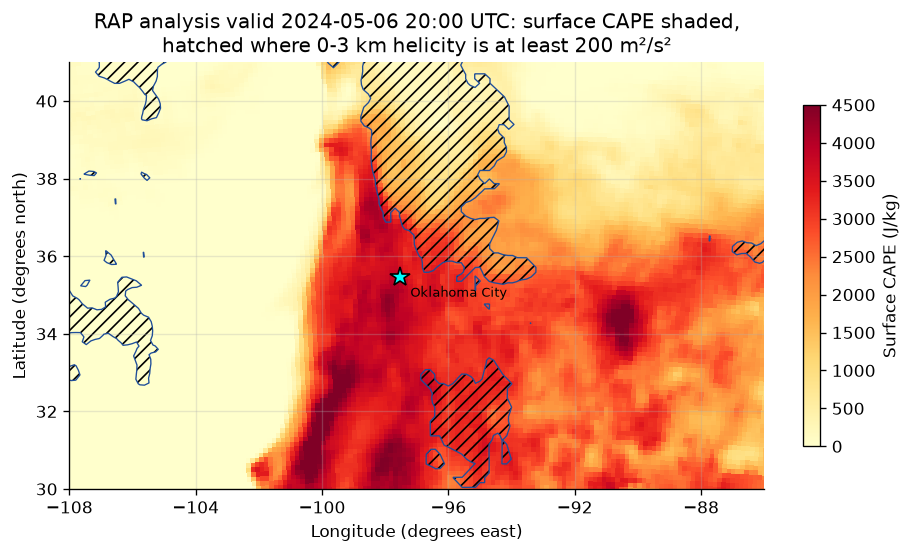

In [7]:
plains = (latitude >= 29) & (latitude <= 42) & (longitude >= -110) & (longitude <= -84)
rows, cols = np.nonzero(plains)
window = (slice(rows.min(), rows.max() + 1), slice(cols.min(), cols.max() + 1))
lon, lat = longitude[window], latitude[window]

fig, ax = plt.subplots(layout="constrained")
shaded = ax.pcolormesh(
    lon, lat, cape.values[window], cmap="YlOrRd", vmin=0, vmax=4500, shading="nearest"
)
ax.contourf(lon, lat, helicity.values[window], levels=[200, 10_000], colors="none", hatches=["///"])
ax.contour(lon, lat, helicity.values[window], levels=[200], colors="#1f4e99", linewidths=0.8)
ax.plot(-97.52, 35.47, marker="*", markersize=12, color="cyan", markeredgecolor="black")
ax.annotate(
    "Oklahoma City", (-97.52, 35.47), xytext=(6, -12), textcoords="offset points", fontsize=8
)
ax.set(
    xlim=(-108, -86),
    ylim=(30, 41),
    xticks=range(-108, -85, 4),
    aspect=1 / np.cos(np.radians(35.5)),
    title=(
        "RAP analysis valid 2024-05-06 20:00 UTC: surface CAPE shaded,\n"
        "hatched where 0-3 km helicity is at least 200 m²/s²"
    ),
    xlabel="Longitude (degrees east)",
    ylabel="Latitude (degrees north)",
)
fig.colorbar(shaded, ax=ax, label="Surface CAPE (J/kg)", shrink=0.8)
plt.show()

In [8]:
both = (cape.values >= 2000) & (helicity.values >= 200)
print(f"Cells with CAPE >= 2000 J/kg and helicity >= 200 m2/s2: {int(both.sum())}")
nearest = np.where(both, from_city, np.inf)
ny, nx = np.unravel_index(nearest.argmin(), nearest.shape)
print(f"Nearest such cell to Oklahoma City: {from_city[ny, nx]:.0f} km away")
print(f"  at {latitude[ny, nx]:.2f} N {longitude[ny, nx]:.2f} E")
row = cape.values[y]
west = x - 1 - int(np.argmax(row[:x][::-1] < 500))
print(f"CAPE falls below 500 J/kg {from_city[y, west]:.0f} km west of the city")

Cells with CAPE >= 2000 J/kg and helicity >= 200 m2/s2: 1259
Nearest such cell to Oklahoma City: 69 km away
  at 35.59 N -96.77 E
CAPE falls below 500 J/kg 278 km west of the city


West of about 100 degrees west the air was dry and stable; east of that edge,
the dryline, CAPE ran above 2000 J/kg across Oklahoma and Texas, and it drops
below 500 J/kg 278 km west of the city. The strongest low-level shear sat
apart from the most unstable air, in a band from northeast Oklahoma into
Kansas and in a patch over north Texas. Oklahoma City's own cell had
3740 J/kg of CAPE but 141 m²/s² of helicity; the nearest cell with both past
the thresholds is 69 km east of it.

Each value is a 13 km cell of one model run, at 20 UTC, 8 hours 39 minutes
before the Oklahoma County tornado report the
[severe-weather case study](https://usdata.dev/studies/severe-weather-case-study/)
follows. The [HRRR walkthrough](https://usdata.dev/datasets/noaa/hrrr/) maps
the same two fields from the 3 km model at the same hour.

## Pin and cite

`verify` checks the cached bytes against the lockfile. Keep the manifest,
lockfile, and cached bytes together; `pull --update` accepts new ranges after
a republished object is reported as drift.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:rap
  NOAA Rapid Refresh (RAP) was accessed on 2026-09-25 from https://registry.opendata.aws/noaa-rap
  homepage: https://registry.opendata.aws/noaa-rap/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-25; 1 checksummed asset (79,120 bytes) pinned by usdata 0.27.0
  sources: environment


## What was awkward

- Finding the grid point nearest a place takes a few lines of NumPy in every
  model walkthrough, and the 0 to 360 longitude convention has to be undone by
  hand first. The roadmap keeps nearest-grid-point helpers out of scope as
  analysis, so each notebook repeats the idiom.
- The manifest asks for `HLCY:3000-0 m above ground` and the Dataset answers
  with `hlcy_heightAboveGroundLayer_3000`. `variable_for` connects the two,
  but the selector spelling has to be copied exactly from the sidecar or the
  guide's table; nothing in `usdata info` lists a file's selectors.
- Units used to arrive as raw ecCodes strings, `J kg**-1` and `m**2 s**-2`.
  `units` now takes the UDUNITS notation, `J kg-1` and `m2 s-2`, with the file's
  spelling kept in `GRIB_units`; prettier plot labels are still written by hand.
- The map has no coastlines or borders to draw. The 13 km file carries no
  land mask (`LAND:surface` matches nothing in its index), and usdata ships no
  boundaries, so the map zooms to the Plains and labels degrees instead.
- The `grib` extra installs with pip alone on Linux, and on Windows through
  Python 3.13; macOS needs the ecCodes library from conda-forge or Homebrew
  first. The [reader reference](https://docs.usdata.dev/reference/readers/)
  has the details.